# **Aprendizado de Máquina Aplicado à Problemas - SME0860**
## Grupo:
### Leonardo Demore - 15674786
### Arthur Araujo - 14651458
### Arthur Filliettaz - 12532055

## Conjunto de Dados: **IEXO - Intoxicação Exógena**

# Parte 1: Exploração e Análise de Dados + <br>Pré-Processamento

## Baixando o conjunto de dados:

In [1]:
from pysus.online_data import SINAN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gdown

In [ ]:
# Download dos dados pelo pysus (rodar se necesśario)
AGRAVO = 'IEXO'
ANOS = [2021, 2022, 2023] 

try:
    arquivos = SINAN.download(AGRAVO, years=ANOS)
    
    # Concatena tudo em um único dataframe
    df = pd.concat([arq.to_dataframe() for arq in arquivos], ignore_index=True)

    print(f"Sucesso! Dataset carregado com {df.shape[0]} linhas e {df.shape[1]} colunas.")
    
except Exception as e:
    print(f"Ocorreu um erro: {e}")

IEXOBR23.parquet: 100%|██████████| 1.08M/1.08M [00:12<00:00, 84.4kB/s]


Sucesso! Dataset carregado com 589058 linhas e 82 colunas.


### Nós subimos o conjunto de dados para uma hospedagem externa, para que possa ser baixado mais facilmente depois

In [2]:
# Baixando o Dataset (rodar se necessário)
FILE_ID = "1SqHCiToyoIw4JhkhJzIkl5jL83erbE_-"
OUTPUT = "dataset.csv"

url = f"https://drive.google.com/uc?id={FILE_ID}"
gdown.download(url, OUTPUT, quiet=False)
df = pd.read_csv(OUTPUT)

Downloading...
From (original): https://drive.google.com/uc?id=1SqHCiToyoIw4JhkhJzIkl5jL83erbE_-
From (redirected): https://drive.google.com/uc?id=1SqHCiToyoIw4JhkhJzIkl5jL83erbE_-&confirm=t&uuid=e66d1cd5-3919-4855-b583-e7281aeec8dd
To: /home/leodemore/GitHub/amap/dataset.csv
100%|██████████| 242M/242M [00:21<00:00, 11.2MB/s] 
/tmp/ipykernel_14872/19982935.py:7: DtypeWarning: Columns (23,42,43,50,56,58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(OUTPUT)


## Começando a exploração:


In [2]:
df = pd.read_csv("dataset.csv")
# "Cara" do dataframe
display(df.head())

# Mostra as colunas, um resumo estatístico e nulos 
df.info()

/tmp/ipykernel_20135/4292583974.py:1: DtypeWarning: Columns (23,42,43,50,56,58) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("dataset.csv")


,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,SEM_NOT,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,ID_UNIDADE,...,TRAB_DESC,LOC_EXP_DE,OUT_AGENTE,UTIL_DESC,LAVOURA,CIRCUN_DES,NU_LOTE_I,INTOX_CHUM,INTOX_MERC,INTOX_META
0,0,2,T659,2021-05-25,202121,2021,31,311910,1467.0,2156458,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
1,1,2,T659,2021-05-25,202121,2021,31,311910,1467.0,2156458,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
2,2,2,T659,2021-05-25,202121,2021,41,411750,1369.0,2781832,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
3,3,2,T659,2021-05-25,202121,2021,26,261160,1497.0,1015,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN
4,4,2,T659,2021-05-25,202121,2021,35,353870,1345.0,2061724,...,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 589058 entries, 0 to 589057
Data columns (total 83 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   Unnamed: 0  589058 non-null  int64  
 1   TP_NOT      589058 non-null  int64  
 2   ID_AGRAVO   589058 non-null  object 
 3   DT_NOTIFIC  589058 non-null  object 
 4   SEM_NOT     589058 non-null  int64  
 5   NU_ANO      589058 non-null  int64  
 6   SG_UF_NOT   589058 non-null  int64  
 7   ID_MUNICIP  589058 non-null  int64  
 8   ID_REGIONA  535381 non-null  float64
 9   ID_UNIDADE  589058 non-null  int64  
 10  DT_SIN_PRI  589058 non-null  object 
 11  SEM_PRI     589058 non-null  int64  
 12  ANO_NASC    582670 non-null  float64
 13  NU_IDADE_N  589058 non-null  int64  
 14  CS_SEXO     589058 non-null  object 
 15  CS_GESTANT  589050 non-null  float64
 16  CS_RACA     586310 non-null  float64
 17  CS_ESCOL_N  556339 non-null  float64
 18  SG_UF       589016 non-null  float64
 19  ID

### Escolhendo Quais colunas vamos manter na análise

In [3]:
columns = [
    'DT_NOTIFIC', 'ID_OCUPA_N', 'SIT_TRAB', 'LOC_EXPO', 'UF_EMP', 'MUN_EMP',
    'AGENTE_TOX', 'VIA_1', 'CIRCUNSTAN',
    'DOENCA_TRA', 'TPEXP', 'NUTEMPO', 'TPTEMPO', 'TPATENDE', 'HOSPITAL',
    'DTINTERNA', 'CLASSI_FIN', 'EVOLUCAO',
    'DT_OBITO', 'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT',
    'CS_RACA', 'CS_ESCOL_N'
]

# Verifica se alguma coluna escolhida para manter não existe
present_columns = [c for c in columns if c in df.columns]
missing_columns = [c for c in columns if c not in df.columns]

print(f"Colunas da lista que não existem no dataset: {missing_columns}")

# mantém apenas as colunas relevantes
df = df[present_columns].copy()

# Prints para avaliação
print(f"DataFrame filtrado: {df.shape[0]} linhas x {df.shape[1]} colunas")
display(df.head(5))

Colunas da lista que não existem no dataset: []
DataFrame filtrado: 589058 linhas x 24 colunas


,DT_NOTIFIC,ID_OCUPA_N,SIT_TRAB,LOC_EXPO,UF_EMP,MUN_EMP,AGENTE_TOX,VIA_1,CIRCUNSTAN,DOENCA_TRA,...,HOSPITAL,DTINTERNA,CLASSI_FIN,EVOLUCAO,DT_OBITO,NU_IDADE_N,CS_SEXO,CS_GESTANT,CS_RACA,CS_ESCOL_N
0,2021-05-25,999991,NaN,1.0,31.0,311910.0,1.0,1.0,10.0,2.0,...,2.0,NaN,2.0,1.0,NaN,4015,F,5.0,1.0,5.0
1,2021-05-25,NaN,99.0,1.0,31.0,311910.0,12.0,1.0,2.0,2.0,...,2.0,NaN,2.0,1.0,NaN,4002,F,6.0,4.0,10.0
2,2021-05-25,NaN,5.0,1.0,41.0,411750.0,8.0,3.0,1.0,2.0,...,2.0,NaN,2.0,1.0,NaN,4029,M,6.0,1.0,6.0
3,2021-05-25,NaN,99.0,1.0,26.0,261160.0,7.0,1.0,10.0,2.0,...,2.0,NaN,1.0,1.0,NaN,4013,F,9.0,4.0,9.0
4,2021-05-25,NaN,99.0,1.0,35.0,353870.0,1.0,1.0,10.0,2.0,...,1.0,20210525.0,2.0,1.0,NaN,4021,F,9.0,4.0,6.0


### Aplicando pré-processamento para poder explorar os dados corretamente

In [4]:
# Dicionário das principais variaveis (facilita o entendimento dos dados)
dictionary = {
'CS_SEXO': {'M': 'Masculino', 'F': 'Feminino', 'I': 'Ignorado'},

'CS_GESTANT': {
    1.0: '1º Trimestre', 2.0: '2º Trimestre', 3.0: '3º Trimestre',
    4.0: 'Idade Gest. Ignorada', 5.0: 'Não', 6.0: 'Não se aplica', 9.0: 'Ignorado'
},

'CS_RACA': {
    1.0: 'Branca', 2.0: 'Preta', 3.0: 'Amarela',
    4.0: 'Parda', 5.0: 'Indígena', 9.0: 'Ignorado'
},

'CS_ESCOL_N': {
    0.0: 'Analfabeto', 1.0: '1ª-4ª série incompleta', 2.0: '4ª série completa',
    3.0: '5ª-8ª série incompleta', 4.0: 'Fundamental completo', 5.0: 'Médio incompleto',
    6.0: 'Médio completo', 7.0: 'Superior incompleto', 8.0: 'Superior completo',
    9.0: 'Não se aplica', 10.0: 'Ignorado'
},

'LOC_EXPO': {
    1.0: 'Residência', 2.0: 'Habitação coletiva', 3.0: 'Creche',
    4.0: 'Instituição de ensino', 5.0: 'Trabalho', 6.0: 'Unidade de saúde',
    7.0: 'Via pública', 8.0: 'Outros', 9.0: 'Ignorado'
},

'AGENTE_TOX': {
    1.0: 'Medicamento', 2.0: 'Agrotóxico (Uso Agrícola)', 3.0: 'Agrotóxico (Uso Doméstico)',
    4.0: 'Agrotóxico (Saúde Pública)', 5.0: 'Raticida', 6.0: 'Produto veterinário',
    7.0: 'Domissanitário', 8.0: 'Cosmético', 9.0: 'Produto químico industrial',
    10.0: 'Metal', 11.0: 'Droga de abuso', 12.0: 'Planta', 13.0: 'Alimento',
    14.0: 'Outro', 99.0: 'Ignorado'
},

'VIA_1': {
    1.0: 'Digestiva', 2.0: 'Respiratória', 3.0: 'Cutânea',
    4.0: 'Ocular', 5.0: 'Parenteral', 6.0: 'Outras',
    7.0: 'Placentária', 9.0: 'Ignorado'
},

'CIRCUNSTAN': {
    1.0: 'Uso habitual', 2.0: 'Acidental', 3.0: 'Ambiental',
    4.0: 'Uso terapêutico', 5.0: 'Prescrição médica inadequada', 6.0: 'Erro de administração',
    7.0: 'Automedicação', 8.0: 'Abuso', 9.0: 'Ingestão de alimento',
    10.0: 'Tentativa de suicídio', 11.0: 'Violência / Homicídio', 12.0: 'Uso ocupacional',
    13.0: 'Outra', 99.0: 'Ignorado'
},

'TPEXP': {1.0: 'Aguda-única', 2.0: 'Aguda-repetida', 3.0: 'Crônica', 9.0: 'Ignorado'},

'SIT_TRAB': {
        1.0: 'Empregado com carteira', 
        2.0: 'Empregado sem carteira', 
        3.0: 'Autônomo/conta própria',
        4.0: 'Servidor público estatutário', 
        5.0: 'Servidor público celetista', 
        6.0: 'Aposentado',
        7.0: 'Desempregado', 
        8.0: 'Trabalho temporário', 
        9.0: 'Cooperativado', 
        10.0: 'Trabalhador avulso',
        11.0: 'Empregador', 
        12.0: 'Outros', 
        99.0: 'Ignorado'
    },

'CLASSI_FIN': {
    1.0: 'Confirmado', 2.0: 'Exposição', 3.0: 'Reação Adversa',
    4.0: 'Diagnóstico Diferencial', 5.0: 'Descartado'
},

'EVOLUCAO': {
    1.0: 'Cura sem sequela',
    2.0: 'Cura com sequela',
    3.0: 'Óbito por Intoxicação Exógena',
    4.0: 'Óbito por outras causas',
    5.0: 'Perda de seguimento',
    9.0: 'Ignorado'
}}

In [5]:
# Cria uma cópia para não alterar o df diretamente
df_raw = df.copy()

# Lista das colunas que precisam ser lidas como número
obj_to_numeric = [
    'SIT_TRAB', 'LOC_EXPO', 'UF_EMP', 'MUN_EMP', 'AGENTE_TOX',
    'UTILIZACAO', 'VIA_1', 'CIRCUNSTAN', 'DOENCA_TRA', 'TPEXP',
    'TPTEMPO', 'TPATENDE', 'HOSPITAL', 'CLASSI_FIN', 'EVOLUCAO',
    'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N'
]

# Converte para número de fato
for col in obj_to_numeric:
    if col in df_raw.columns:
        df_raw[col] = pd.to_numeric(df_raw[col], errors='coerce')

# Padroniza outliers (homens com gravidez != de "não se aplica")
if 'CS_SEXO' in df_raw.columns and 'CS_GESTANT' in df_raw.columns:
    df_raw.loc[(df_raw['CS_SEXO'] == 'M') & (df_raw['CS_GESTANT'].isin([5.0, 9.0])), 'CS_GESTANT'] = 6.0

# Cria uma nova coluna com a descrição da coluna numérica 
for col, mapping in dictionary.items():
    if col in df_raw.columns:
        df_raw[f"{col}_DESC"] = df_raw[col].map(mapping)

# Converte datas para o formato correto
for col in ['DT_NOTIFIC', 'DTINTERNA', 'DT_OBITO']:
    if col in df_raw.columns:
        df_raw[col] = pd.to_datetime(df_raw[col], errors='coerce')

# Convertendo as idades para formato legível
def decode_idade(x):
    try:
        s = str(int(x)).zfill(4)
        unid, val = s[0], int(s[1:])
        if unid == '4': return val
        if unid == '3': return val / 12
        if unid == '2': return val / 365
        return np.nan
    except: 
        return np.nan

if 'NU_IDADE_N' in df_raw.columns:
    df_raw['IDADE_ANOS'] = df_raw['NU_IDADE_N'].apply(decode_idade)
    
    # Tratando os outliers de idade
    df_raw.loc[df_raw['IDADE_ANOS'] > 110, 'IDADE_ANOS'] = np.nan

if 'NUTEMPO' in df_raw.columns:
    df_raw['NUTEMPO'] = df_raw['NUTEMPO'].astype(str).str.extract(r'(\d+)').astype(float)

display(df_raw)


,DT_NOTIFIC,ID_OCUPA_N,SIT_TRAB,LOC_EXPO,UF_EMP,MUN_EMP,AGENTE_TOX,VIA_1,CIRCUNSTAN,DOENCA_TRA,...,CS_ESCOL_N_DESC,LOC_EXPO_DESC,AGENTE_TOX_DESC,VIA_1_DESC,CIRCUNSTAN_DESC,TPEXP_DESC,SIT_TRAB_DESC,CLASSI_FIN_DESC,EVOLUCAO_DESC,IDADE_ANOS
0,2021-05-25,999991,NaN,1.0,31.0,311910.0,1.0,1.0,10.0,2.0,...,Médio incompleto,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,NaN,Exposição,Cura sem sequela,15.0
1,2021-05-25,NaN,99.0,1.0,31.0,311910.0,12.0,1.0,2.0,2.0,...,Ignorado,Residência,Planta,Digestiva,Acidental,Aguda-única,Ignorado,Exposição,Cura sem sequela,2.0
2,2021-05-25,NaN,5.0,1.0,41.0,411750.0,8.0,3.0,1.0,2.0,...,Médio completo,Residência,Cosmético,Cutânea,Uso habitual,Aguda-única,Servidor público celetista,Exposição,Cura sem sequela,29.0
3,2021-05-25,NaN,99.0,1.0,26.0,261160.0,7.0,1.0,10.0,2.0,...,Não se aplica,Residência,Domissanitário,Digestiva,Tentativa de suicídio,Aguda-única,Ignorado,Confirmado,Cura sem sequela,13.0
4,2021-05-25,NaN,99.0,1.0,35.0,353870.0,1.0,1.0,10.0,2.0,...,Médio completo,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Ignorado,Exposição,Cura sem sequela,21.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589053,2023-10-03,NaN,99.0,1.0,42.0,421550.0,7.0,3.0,1.0,2.0,...,Não se aplica,Residência,Domissanitário,Cutânea,Uso habitual,Aguda-única,Ignorado,Exposição,Cura sem sequela,30.0
589054,2023-10-03,NaN,2.0,1.0,43.0,430790.0,1.0,1.0,10.0,2.0,...,Médio completo,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Empregado sem carteira,Confirmado,Cura sem sequela,27.0
589055,2023-10-03,516110,3.0,1.0,41.0,410690.0,1.0,1.0,10.0,2.0,...,Médio completo,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Autônomo/conta própria,Confirmado,Cura sem sequela,35.0
589056,2023-10-03,999992,12.0,1.0,33.0,330420.0,1.0,1.0,10.0,2.0,...,Não se aplica,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Outros,Confirmado,Cura sem sequela,52.0


### Após este processamento, vamos verificar como os nulos se comportam e dropar aqueles que não servem 

In [6]:
# Calcula a porcentagem de nulos por coluna
nan_percentual = (df_raw.isna().sum() / len(df_raw)) * 100

# Filtra apenas as colunas que têm 
# algum nulo (quase todas) e ordena 
nans = nan_percentual[nan_percentual > 0].sort_values(ascending=False)

print("PORCENTAGEM DE NULOS POR COLUNA")
print(nans.round(2).astype(str) + ' %')

PORCENTAGEM DE NULOS POR COLUNA
DT_OBITO            99.1 %
DTINTERNA          69.11 %
ID_OCUPA_N         53.58 %
TPTEMPO            13.75 %
SIT_TRAB_DESC      13.41 %
SIT_TRAB           13.41 %
MUN_EMP            13.07 %
UF_EMP             12.88 %
CLASSI_FIN_DESC    11.89 %
TPEXP_DESC          9.23 %
EVOLUCAO_DESC       8.74 %
EVOLUCAO            8.74 %
TPEXP               7.62 %
AGENTE_TOX          6.47 %
AGENTE_TOX_DESC     6.47 %
VIA_1_DESC          6.45 %
VIA_1               6.17 %
CS_ESCOL_N          5.55 %
CS_ESCOL_N_DESC     5.55 %
HOSPITAL            5.52 %
TPATENDE            4.14 %
DOENCA_TRA           4.1 %
LOC_EXPO            3.78 %
LOC_EXPO_DESC       3.78 %
NUTEMPO              3.3 %
CIRCUNSTAN          3.28 %
CIRCUNSTAN_DESC     3.28 %
CLASSI_FIN          0.51 %
CS_RACA_DESC        0.47 %
CS_RACA             0.47 %
IDADE_ANOS          0.02 %
CS_GESTANT_DESC      0.0 %
CS_GESTANT           0.0 %
dtype: object


### Análise dos nulos: 
- DT_OBITO: Faz sentido ser quase totalmente nula, pois pouquíssimas internações por intoxicação exógena levam a óbito
- DT_INTERNA: Segue uma lógica parecida, a maioria dos casos não requer internação
- ID_OCUPA_N: Muitos NaNs pois esse dado não é levantado com frequência, e o principal motivo é que muitos idosos e crianças não possuem ocupação

Os outros nulos são apenas ruído nos dados

In [7]:
# Engenharia de Feature com a Data de Internação:
# Vamos transformar a data em uma coluna binária, onde
# 1 indica internação e 0 indica não internado
if 'DTINTERNA' in df_raw.columns:
    df_raw['INTERNADO'] = df_raw['DTINTERNA'].notna().astype(int)
    df_raw = df_raw.drop(columns=['DTINTERNA']) # Remove a original

# Dropa instâncias onde não pode haver nulos 
# Lista com as colunas finais onde os nulos não são aceitáveis
    important = [
        'CS_ESCOL_N_DESC', 'CS_ESCOL_N', 
        'VIA_1_DESC', 'VIA_1', 
        'HOSPITAL', 'TPATENDE', 
        'NUTEMPO', 
        'LOC_EXPO', 'LOC_EXPO_DESC', 
        'DOENCA_TRA', 
        'CIRCUNSTAN_DESC', 'CIRCUNSTAN', 
        'CS_RACA_DESC', 'CS_RACA', 
        'CS_GESTANT_DESC', 'CS_GESTANT',
        'EVOLUCAO', 'EVOLUCAO_DESC',
        'AGENTE_TOX', 'AGENTE_TOX_DESC', 'IDADE_ANOS'
    ]
df_raw = df_raw.dropna(subset=important)

# Preenche o restante "Ignorado" para aproveitar os dados
to_fill = [
    'TPTEMPO', 'SIT_TRAB', 'MUN_EMP', 'UF_EMP', 
    'CLASSI_FIN', 'CLASSI_FIN_DESC', 'TPEXP', 'TPEXP_DESC',
    'SIT_TRAB_DESC'
]

for col in to_fill:
    if col in df_raw.columns:
        # Se for uma coluna de texto 
        if df_raw[col].dtype == 'object':
            df_raw[col] = df_raw[col].fillna('Ignorado')
        # Se for numérica 
        else:
            df_raw[col] = df_raw[col].fillna(99.0)

In [8]:
display(df_raw)

# calculando os nulos novamente
nan_percentual = (df_raw.isna().sum() / len(df_raw)) * 100

# Filtra apenas as colunas que têm 
# algum nulo (quase todas) e ordena 
nans = nan_percentual[nan_percentual > 0].sort_values(ascending=False)

print("PORCENTAGEM DE NULOS POR COLUNA")
print(nans.round(2).astype(str) + ' %')


,DT_NOTIFIC,ID_OCUPA_N,SIT_TRAB,LOC_EXPO,UF_EMP,MUN_EMP,AGENTE_TOX,VIA_1,CIRCUNSTAN,DOENCA_TRA,...,LOC_EXPO_DESC,AGENTE_TOX_DESC,VIA_1_DESC,CIRCUNSTAN_DESC,TPEXP_DESC,SIT_TRAB_DESC,CLASSI_FIN_DESC,EVOLUCAO_DESC,IDADE_ANOS,INTERNADO
0,2021-05-25,999991,99.0,1.0,31.0,311910.0,1.0,1.0,10.0,2.0,...,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Ignorado,Exposição,Cura sem sequela,15.0,0
1,2021-05-25,NaN,99.0,1.0,31.0,311910.0,12.0,1.0,2.0,2.0,...,Residência,Planta,Digestiva,Acidental,Aguda-única,Ignorado,Exposição,Cura sem sequela,2.0,0
2,2021-05-25,NaN,5.0,1.0,41.0,411750.0,8.0,3.0,1.0,2.0,...,Residência,Cosmético,Cutânea,Uso habitual,Aguda-única,Servidor público celetista,Exposição,Cura sem sequela,29.0,0
3,2021-05-25,NaN,99.0,1.0,26.0,261160.0,7.0,1.0,10.0,2.0,...,Residência,Domissanitário,Digestiva,Tentativa de suicídio,Aguda-única,Ignorado,Confirmado,Cura sem sequela,13.0,0
4,2021-05-25,NaN,99.0,1.0,35.0,353870.0,1.0,1.0,10.0,2.0,...,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Ignorado,Exposição,Cura sem sequela,21.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
589053,2023-10-03,NaN,99.0,1.0,42.0,421550.0,7.0,3.0,1.0,2.0,...,Residência,Domissanitário,Cutânea,Uso habitual,Aguda-única,Ignorado,Exposição,Cura sem sequela,30.0,0
589054,2023-10-03,NaN,2.0,1.0,43.0,430790.0,1.0,1.0,10.0,2.0,...,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Empregado sem carteira,Confirmado,Cura sem sequela,27.0,1
589055,2023-10-03,516110,3.0,1.0,41.0,410690.0,1.0,1.0,10.0,2.0,...,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Autônomo/conta própria,Confirmado,Cura sem sequela,35.0,1
589056,2023-10-03,999992,12.0,1.0,33.0,330420.0,1.0,1.0,10.0,2.0,...,Residência,Medicamento,Digestiva,Tentativa de suicídio,Aguda-única,Outros,Confirmado,Cura sem sequela,52.0,1


PORCENTAGEM DE NULOS POR COLUNA
DT_OBITO      99.04 %
ID_OCUPA_N    50.39 %
dtype: object


### Agora os dados estão limpos e podemos começar com a análise gráfica

In [10]:
df_raw.to_csv("processed_df.csv", index=False)

## Plots

In [11]:
# Baixando o Dataset (rodar se necessário)
FILE_ID = "1XO6vC_Fw6n29BXxba-ZPryh7A0wf0egw"
OUTPUT = "processed_df.csv"

url = f"https://drive.google.com/uc?id={FILE_ID}"
gdown.download(url, OUTPUT, quiet=False)
df = pd.read_csv(OUTPUT)

Downloading...
From (original): https://drive.google.com/uc?id=1XO6vC_Fw6n29BXxba-ZPryh7A0wf0egw
From (redirected): https://drive.google.com/uc?id=1XO6vC_Fw6n29BXxba-ZPryh7A0wf0egw&confirm=t&uuid=6f0822a1-6154-4623-97cc-95959bf500a9
To: /home/leodemore/GitHub/amap/processed_df.csv
100%|██████████| 116M/116M [00:10<00:00, 10.9MB/s] 


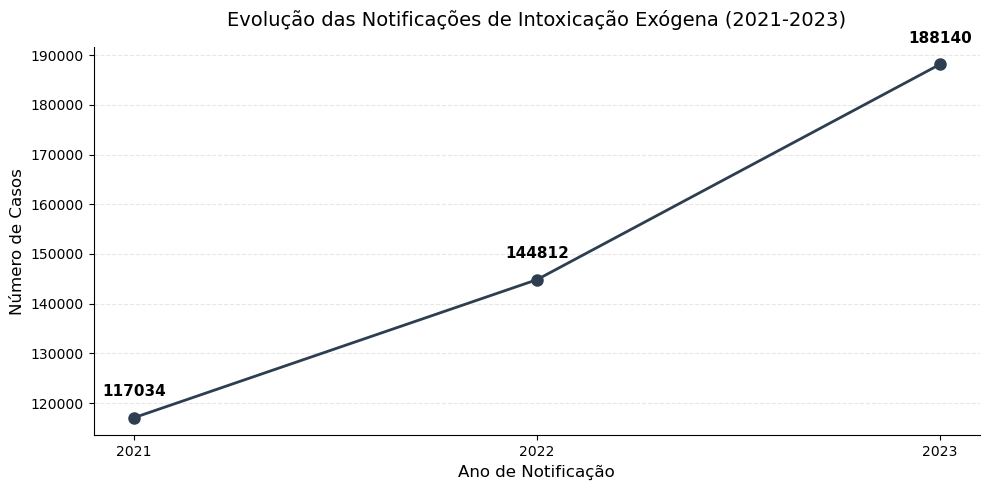

In [13]:
# 1. Extração e contagem segura dos dados
df['DT_NOTIFIC'] = pd.to_datetime(df['DT_NOTIFIC'], errors='coerce')
contagem_anos = df['DT_NOTIFIC'].dt.year.value_counts().sort_index()

# 2. Configuração da figura
plt.figure(figsize=(10, 5))
contagem_anos.plot(kind='line', marker='o', color='#2c3e50', lw=2, markersize=8)

# 3. Títulos e rótulos atualizados para a realidade dos dados
plt.title('Evolução das Notificações de Intoxicação Exógena (2021-2023)', fontsize=14, pad=15)
plt.xlabel('Ano de Notificação', fontsize=12)
plt.ylabel('Número de Casos', fontsize=12)

# 4. Força o eixo X a mostrar apenas os anos exatos (inteiros)
plt.xticks(contagem_anos.index)

# 5. Adiciona os números exatos em cima de cada ponto do gráfico
for ano, valor in zip(contagem_anos.index, contagem_anos.values):
    # O valor * 0.02 empurra o texto um pouquinho para cima da bolinha
    plt.text(ano, valor + (max(contagem_anos.values) * 0.02), f'{int(valor)}', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 6. Estética limpa (Grid e remoção de bordas)
plt.grid(axis='y', alpha=0.3, linestyle='--')
sns.despine() # Remove as bordas superior e direita do gráfico
plt.tight_layout()

plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='AGENTE_TOX_DESC',
              order=df['AGENTE_TOX_DESC'].value_counts().index[:10],
              palette='viridis')

plt.title('Top 10 Agentes Causadores de Intoxicação', fontsize=14)
plt.xlabel('Número de Notificações')
plt.ylabel('Agente Tóxico')
plt.show()

In [ ]:
top_agentes = df['AGENTE_TOX_DESC'].value_counts().nlargest(10).index
top_circ = df['CIRCUNSTAN_DESC'].value_counts().nlargest(10).index

df_pivot = df[df['AGENTE_TOX_DESC'].isin(top_agentes) & df['CIRCUNSTAN_DESC'].isin(top_circ)]
ct = pd.crosstab(df_pivot['AGENTE_TOX_DESC'], df_pivot['CIRCUNSTAN_DESC'], normalize='index')

plt.figure(figsize=(12, 7))
sns.heatmap(ct, annot=True, cmap="YlGnBu", fmt='.2f')
plt.title('Relação Percentual: Agente Tóxico vs. Circunstância', fontsize=14)
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(x=df['DT_NOTIFIC'].dt.month, palette='coolwarm')
plt.title('Distribuição Mensal: Há sazonalidade nos casos?', fontsize=14)
plt.xlabel('Mês')
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df, x='IDADE_ANOS', hue='CS_SEXO_DESC', fill=True, common_norm=False, alpha=0.4)
plt.title('Pirâmide de Densidade: Idade vs Sexo', fontsize=14)
plt.xlim(0, 100)
plt.show()

In [ ]:
total_casos = df['AGENTE_TOX_DESC'].value_counts()

obitos = df[df['EVOLUCAO_DESC'] == 'Óbito por Intoxicação Exógena']['AGENTE_TOX_DESC'].value_counts()

taxa_letalidade = (obitos / total_casos * 100).fillna(0).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
taxa_letalidade.plot(kind='barh', color='#c0392b')
plt.title('Top 10 Agentes com Maior Taxa de Letalidade (%)', fontsize=14)
plt.xlabel('Letalidade (Óbitos / Total de Casos do Agente * 100)')
plt.ylabel('Agente Tóxico')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
df_local = (df['LOC_EXPO_DESC'].value_counts(normalize=True).head(7) * 100).reset_index()
df_local.columns = ['Local', 'Percentual']

plt.figure(figsize=(10, 6))
sns.barplot(data=df_local, x='Percentual', y='Local', palette='mako')

plt.title('Principais Locais de Exposição (%)')
plt.xlabel('Percentual (%)')
plt.ylabel('Local')
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='SIT_TRAB_DESC', data=df, order=df['SIT_TRAB_DESC'].value_counts().index, palette='mako')
plt.title('Distribuição por Situação de Trabalho', fontsize=14)
plt.show()

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df['CS_RACA_DESC'].value_counts().plot(kind='bar', ax=ax1, color='skyblue')
ax1.set_title('Casos por Raça/Cor')

df['CS_ESCOL_N_DESC'].value_counts().plot(kind='bar', ax=ax2, color='salmon')
ax2.set_title('Casos por Escolaridade')
plt.show()